# Note on the implementation

Most of the initial implementation was provided as course material in BERN02. My work focused on running and understanding the implementation, writing comments, interpreting the different components of the neural network, experimenting with the provided code, and making modifications where appropriate.\
\
## My contribution

- Studied and interpreted the provided neural network implementation
- Ran and evaluated the model on bird and dog image data
- Analysed the forward and backward propagation steps
- Experimented with model parameters and training behaviour
- Modified parts of the provided implementation
- Documented and commented on the code

### Model

* Three convolutional layers (32, 64, 128 filters)
* LeakyReLU activation
* MaxPooling
* Flatten + fully connected layer
* Softmax classification
* Adam optimizer
* Categorical cross-entropy loss
* Dropout experiment for regularization

### Data preprocessing

* Bird and dog image classification
* Images resized to 32 × 32 pixels
* Train/validation/test split
* One-hot encoded labels

### Evaluation

* Training and validation accuracy
* Training and validation loss
* Test accuracy
* Comparison of training and validation performance
* Investigation of overfitting

### Results

Test accuracy: 71.4%

The baseline model showed clear signs of overfitting, motivating an additional experiment with dropout.

### Technologies

Python, TensorFlow/Keras, OpenCV, NumPy, Matplotlib, scikit-learn


# Convolutional Bird Dog Modelling with Keras
It's a deep, feed-forward only artificial neural network also called multi-layer perceptrons(MLPs).
CNNs are inspired by the biological visual cortex.
Convolutional neural networks performe a lot better than traditional computer vision.

- The CNN very efficiently perform calculations of the input with a small matrix (here 3x3) that is effectivly sliding over the image.
- Then transfer function that has a suppression effect, here leaky ReLU is used. 
- Maxpooling to reduce the dimensions of the image. This technique takes the max values of a smaller section of the image that is currently covered by the kernel. This is useful to reduce oversampling. 
- Classic optimizer

In [ ]:
import sys,os
import numpy as np                     #main package for scientific computing with Python.
import pandas as pd                    #main data handling package
from matplotlib import image           #plot graphs in Python.
import matplotlib.pyplot as plt        #lazy plotting
import cv2                             #image opening
import keras

from keras.models import Sequential,Model
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import LeakyReLU
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical


### Plot the "LeakyReLU"

Text(-0.75, 0, 'Leak=0.1*x')

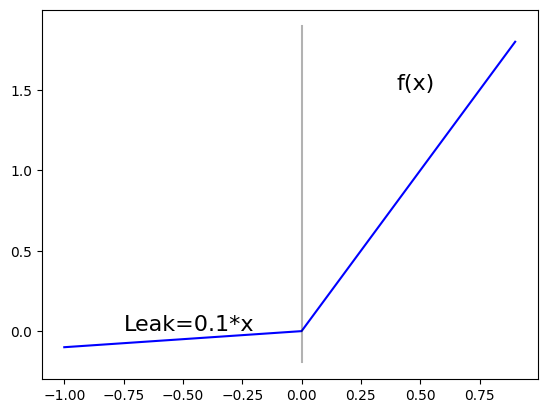

In [ ]:
#Leaky Rectified Linear Unit
x=np.arange(-1,1,0.1);y=2*x;y[x<0]=0.1*x[x<0]
fig,ax=plt.subplots();ax.plot(x,y,'blue');ax.plot([0,0],ax.get_ylim(),'black',alpha=0.3)
ax.text(x=0.4,y=1.5,s='f(x)',fontsize=16);ax.text(x=-0.75,y=0,s='Leak=0.1*x',fontsize=16)

In [ ]:
# Load data from specific github folder for this course, this code is meant to run in Google Colab.
if "google.colab" in sys.modules:
    path_to_files = os.sep.join([os.getcwd(), "Bern02", "Labs", "Neural_Networks", "train"])
    !git clone https://github.com/luchem/Bern02.git --depth=1
else:
    path_to_files = os.sep.join([os.getcwd(), "train"])

# Create two empty lists to store the data (the images) and the labels (0 if bird, 1 if dog)
data=[]
labels=[]
image_size=32
# Load the data into the notebook from the folder on the computer
for filename in os.listdir(os.sep.join([path_to_files,'bird'])):
    labels.append(0)
    data.append(cv2.resize(image.imread(os.sep.join([path_to_files,'bird',filename])),dsize=(image_size,image_size)))
for filename in os.listdir(os.sep.join([path_to_files,'dog'])):
    labels.append(1)
    data.append(cv2.resize(image.imread(os.sep.join([path_to_files,'dog',filename])),dsize=(image_size,image_size)))
data=np.array(data)
labels=np.array(labels)

fatal: destination path 'Bern02' already exists and is not an empty directory.


In [ ]:
np.random.seed(0)
idx=np.random.permutation(len(labels))
idx_train=idx[0:2200]
idx_test=idx[2201:2401]
train_x=data[idx_train]
test_x=data[idx_test]
train_y=labels[idx_train].reshape(1,-1)
test_y=labels[idx_test].reshape(1,-1)

In [ ]:
train_x=data[idx_train]
test_x=data[idx_test]
train_y=labels[idx_train]#.reshape(1,-1)
test_y=labels[idx_test]#.reshape(1,-1)
print('Training data shape : ', train_x.shape, train_y.shape)
print('Testing data shape : ', test_x.shape, test_y.shape)

Training data shape :  (2200, 32, 32, 3) (2200,)
Testing data shape :  (199, 32, 32, 3) (199,)


In [ ]:
classes = np.unique(train_y)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Total number of outputs :  2
Output classes :  [0 1]


Text(0.5, 1.0, 'Bird')

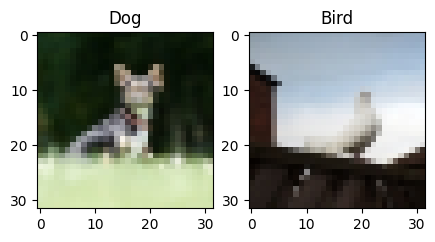

In [ ]:
plt.figure(figsize=[5,5])
def naming(key):
    if key==1:return 'Dog'
    elif key==0: return 'Bird'
    else: raise
# Display the first image in training data
plt.subplot(121)
plt.imshow(train_x[0,:,:,:])
plt.title("{}".format(naming(train_y[0])))
# Display the first image in testing data
plt.subplot(122)
plt.imshow(test_x[0,:,:,:])
plt.title("{}".format(naming(test_y[0])))

In [ ]:
train_x = train_x.reshape(-1, 32,32, 3)
test_x = test_x.reshape(-1, 32,32, 3)
print('Datashape: {}\nTestshape:{}'.format(train_x.shape, test_x.shape))
# Normalization needed
train_x = train_x.astype('float32')
test_x = test_x.astype('float32')
train_x = train_x / 255.
test_x = test_x / 255.

Datashape: (2200, 32, 32, 3)
Testshape:(199, 32, 32, 3)


In [ ]:
train_y_one_hot = to_categorical(train_y)
test_y_one_hot = to_categorical(test_y)
# Display the change for category label using one-hot encoding
print('Original label:', train_y[0])
print('After conversion to one-hot:', train_y_one_hot[0])

Original label: 1
After conversion to one-hot: [0. 1.]


In [ ]:
#This would be an automatic way to split the data
train_x,valid_x,train_label,valid_label = train_test_split(train_x, train_y_one_hot, test_size=0.2, random_state=13)
# test the shape
train_x.shape,valid_x.shape,train_label.shape,valid_label.shape

((1760, 32, 32, 3), (440, 32, 32, 3), (1760, 2), (440, 2))

In [ ]:
# Set modelling parameter
batch_size = 50 # load this many
epochs = 30     # Total throughput
num_classes = 2 # Categories

In [ ]:
# Set modelling parameter
batch_size = 50 # load this many
epochs = 50     # Total throughput
num_classes = 2 # Categories

bird_model = Sequential()
bird_model.add(Conv2D(32, kernel_size=(3, 3),activation='linear',input_shape=(32,32,3),padding='same'))
bird_model.add(LeakyReLU(alpha=0.1))
bird_model.add(MaxPooling2D((2, 2),padding='same'))
bird_model.add(Conv2D(64, (3, 3), activation='linear',padding='same'))
bird_model.add(LeakyReLU(alpha=0.1))
bird_model.add(MaxPooling2D(pool_size=(2, 2),padding='same'))
bird_model.add(Conv2D(128, (3, 3), activation='linear',padding='same'))
bird_model.add(LeakyReLU(alpha=0.1))
bird_model.add(MaxPooling2D(pool_size=(2, 2),padding='same'))
bird_model.add(Flatten())
bird_model.add(Dense(128, activation='linear'))
bird_model.add(LeakyReLU(alpha=0.1))
bird_model.add(Dense(num_classes, activation='softmax'))
bird_model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adam(),metrics=['accuracy'])
bird_model.summary()
bird_train = bird_model.fit(train_x, train_label, batch_size=batch_size,epochs=epochs,verbose=1,validation_data=(valid_x, valid_label))
bird_model.save("bird_model_no_dropout.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,778 (1.36 MB)

 Trainable params: 355,778 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - accuracy: 0.5313 - loss: 0.7284 - val_accuracy: 0.5500 - val_loss: 0.6785
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6092 - loss: 0.6557 - val_accuracy: 0.6114 - val_loss: 0.6487
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6853 - loss: 0.5934 - val_accuracy: 0.5773 - val_loss: 0.6609
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6971 - loss: 0.5818 - val_accuracy: 0.6500 - val_loss: 0.6406
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7445 - loss: 0.5173 - val_accuracy: 0.6273 - val_loss: 0.6407
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7559 - loss: 0.4850 - val_accuracy: 0.6295 - val_loss: 0.8318
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7260 - loss: 0.5271 - val_accuracy: 0.6864 - val_loss: 0.5799
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8269 - loss: 0.4030 - val_accuracy: 0.6909 - val_los

Test loss: 1.4327332973480225
Test accuracy: 0.713567852973938


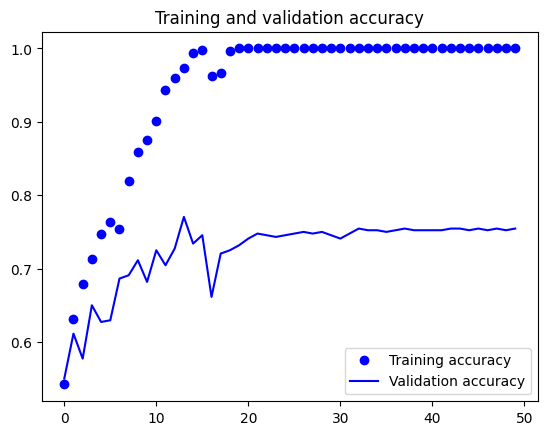

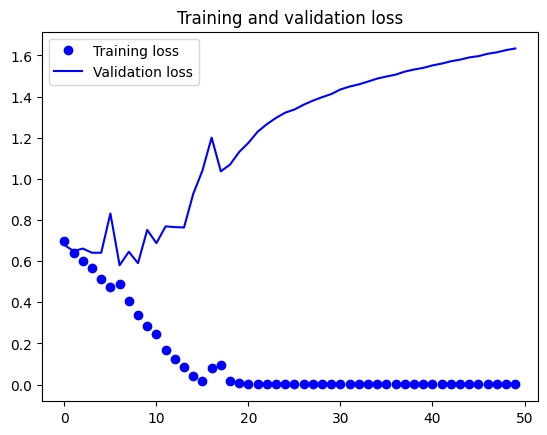

In [ ]:
test_eval = bird_model.evaluate(test_x, test_y_one_hot, verbose=0)
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

accuracy = bird_train.history['accuracy']
val_accuracy = bird_train.history['val_accuracy']
loss = bird_train.history['loss']
val_loss = bird_train.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

## Fix overfitting by freezing a random number of nodes at each step


In [ ]:
# Set modelling parameter
batch_size = 50 # load this many
epochs = 50     # Total throughput
num_classes = 2 # Categories

bird_model = Sequential()
bird_model.add(Conv2D(32, kernel_size=(3, 3),activation='linear',input_shape=(32,32,3),padding='same'))
bird_model.add(LeakyReLU(alpha=0.1))
bird_model.add(MaxPooling2D((2, 2),padding='same'))
bird_model.add(Dropout(0.25))
bird_model.add(Conv2D(64, (3, 3), activation='linear',padding='same'))
bird_model.add(LeakyReLU(alpha=0.1))
bird_model.add(MaxPooling2D(pool_size=(2, 2),padding='same'))
bird_model.add(Dropout(0.25))
bird_model.add(Conv2D(128, (3, 3), activation='linear',padding='same'))
bird_model.add(LeakyReLU(alpha=0.1))
bird_model.add(MaxPooling2D(pool_size=(2, 2),padding='same'))
bird_model.add(Dropout(0.5))
bird_model.add(Flatten())
bird_model.add(Dense(128, activation='linear'))
bird_model.add(LeakyReLU(alpha=0.1))
bird_model.add(Dropout(0.3))
bird_model.add(Dense(num_classes, activation='softmax'))
bird_model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adam(),metrics=['accuracy'])
bird_model.summary()
bird_train = bird_model.fit(train_x, train_label, batch_size=batch_size,epochs=epochs,verbose=1,validation_data=(valid_x, valid_label))
bird_model.save("bird_model_with_dropout.h5")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,778 (1.36 MB)

 Trainable params: 355,778 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.5171 - loss: 0.7021 - val_accuracy: 0.5455 - val_loss: 0.6863
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5357 - loss: 0.6862 - val_accuracy: 0.5727 - val_loss: 0.6648
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5982 - loss: 0.6576 - val_accuracy: 0.5977 - val_loss: 0.6489
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6415 - loss: 0.6332 - val_accuracy: 0.6250 - val_loss: 0.6736
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6476 - loss: 0.6341 - val_accuracy: 0.6136 - val_loss: 0.6362
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6843 - loss: 0.5817 - val_accuracy: 0.6500 - val_loss: 0.6188
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6964 - loss: 0.5643 - val_accuracy: 0.6545 - val_loss: 0.6092
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7243 - loss: 0.5567 - val_accuracy: 0.6750 - val_lo

Test loss: 0.48790088295936584
Test accuracy: 0.8140703439712524


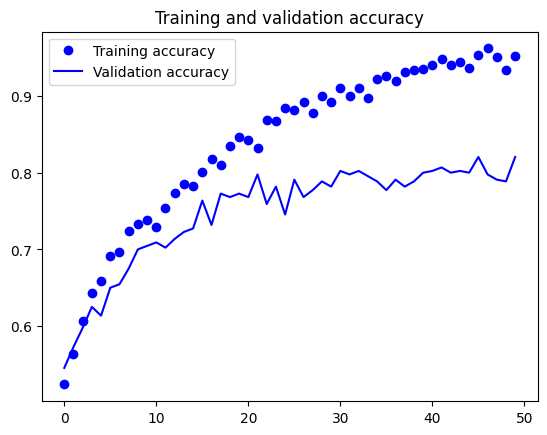

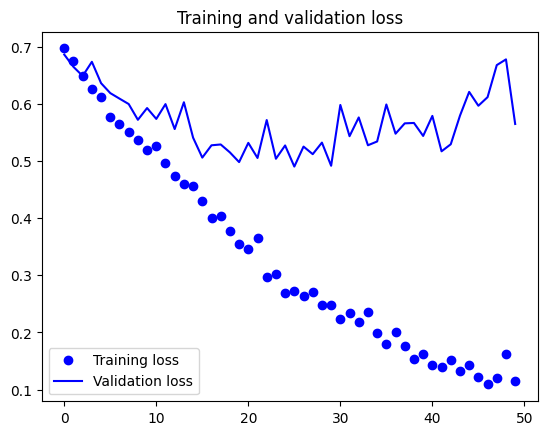

In [ ]:
test_eval = bird_model.evaluate(test_x, test_y_one_hot, verbose=0)
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

accuracy = bird_train.history['accuracy']
val_accuracy = bird_train.history['val_accuracy']
loss = bird_train.history['loss']
val_loss = bird_train.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

The validation accuracy now follows the training data much longer and there is e a much lower loss through the partial freeze. This is due to that bad training images not influence the formation as strong, as always some of the nodes are locked = made resilliant

## Test with virgin data

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
Found 162 correct recognitions (of 199 total)


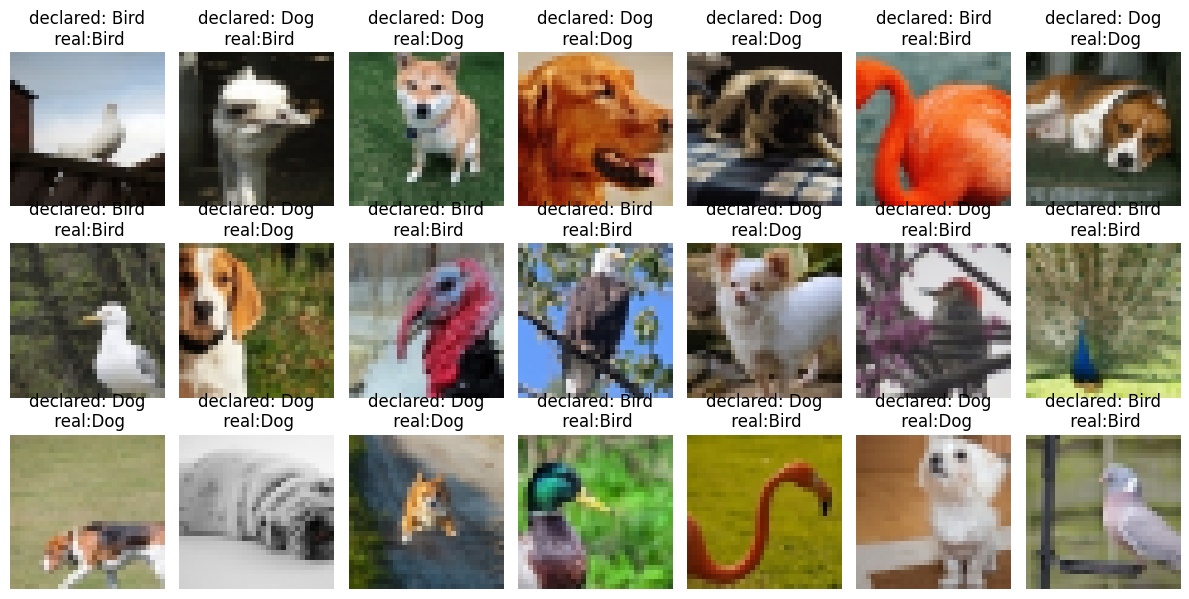

In [ ]:
def naming(key):
    if key==1:return 'Dog'
    elif key==0: return 'Bird'
    else: raise
predicted_classes = bird_model.predict(test_x)
predicted_classes = np.argmax(np.round(predicted_classes),axis=1)
predicted_classes.shape, test_x.shape
correct = np.where(predicted_classes==test_y)[0]
print("Found %d correct recognitions (of %d total)"%(len(correct),len(test_y)))
fig,ax=plt.subplots(3,7,figsize=(12,6))
ax=ax.ravel()
for i in range(21):
    ax[i].imshow(test_x[i].reshape(32,32,3), interpolation='none')
    ax[i].set_title("declared: %s\n real:%s"%(naming(predicted_classes[i]),naming(test_y[i])))
    ax[i].axis('off')
fig.tight_layout()

**compare carefull the two models and identify what is the difference**
One important difference is that the first model uses both forward and backward propagation, and the second "Convolutional Bird Dog Modelling with Keras" uses only feed foward. In the second model an optimizer is used to minimize errors, instead of the error calculation and back propagation as in the first model. In the first model the layers are also manually weighted in the beginning, I can't see this for the second model. As I understand it, the optimizer does approximately the same thing as was manually coded in the first model, but in an automatic and optimized way.
I also understand that the second model, since it uses convolution, does not have all neurons connected to all nodes. Whereas in the first model all neurons are connected to all nodes.
The first model takes a flat vector as input and the second one takes a matrix.
The second model uses maxpooling and dropout which the first one doesn't.

**Why do we use max pooling?**
Maxpooling is used to reduce oversampling and reduce the computational load as it reduces the dimensionality of the data.  

**Why do we use dropout?**
Dropout means that neurons are randomly dropped (set to zero) during training, to prevent overfitting of the model. Using dropout reduces the risk of more neurons being trained for the same features, which is how it reduces overfitting.